# Multistream Matrix-Fractal vs Binary Serial / Многоканальное сравнение с Binary Serial

**RU.** Этот notebook показывает честное ресурсное сравнение: и binary serial, и matrix-fractal получают одинаковое число физических потоков. Payload делится по потокам, а для каждого fractal stream заново строится иерархия каналов.

**EN.** This notebook compares equal physical stream counts. Both binary serial and matrix-fractal transmission receive the same number of streams; the payload is split across streams.

Important / Важно:

- это conservative step-mode baseline, не предельная аппаратная скорость;
- latency для fractal payload зависит от выбранного пользовательского алфавита;
- `ID = payload_bits / (latency_ticks * physical_streams)`.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == 'experiments' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
from snn_framework import ChannelAlphabet, FractalSNNPacketCodec, MatrixFractalNumber
import math
import pandas as pd

In [2]:
sys.path.insert(0,str(ROOT/'article_assets'/'scripts'))
from dynamic_alphabet_helpers import capacity_bits, contiguous_equal_width, digit_count_for_payload, required_payload_ticks, worst_case_value
model=contiguous_equal_width(width=8); rows=[]
for payload_bits in [128,256,512,1024,2048,4096]:
    for streams in [1,4,8,16]:
        segment_bits=math.ceil(payload_bits/streams); dc=digit_count_for_payload(model,segment_bits)
        ticks=required_payload_ticks(model.encode_cells(worst_case_value(model,dc),digit_count=dc))
        rows.append({'method':'matrix_channel_width8','payload_bits':payload_bits,'streams':streams,'digit_count':dc,'latency_ticks':ticks,'id':payload_bits/(ticks*streams)})
        rows.append({'method':'binary_serial','payload_bits':payload_bits,'streams':streams,'digit_count':segment_bits,'latency_ticks':segment_bits,'id':payload_bits/(segment_bits*streams)})
df=pd.DataFrame(rows); df.head()

,method,payload_bits,streams,digit_count,latency_ticks,id
0,matrix_channel_width8,128,1,15,484,0.264463
1,binary_serial,128,1,128,128,1.000000
2,matrix_channel_width8,128,4,5,164,0.195122
3,binary_serial,128,4,32,32,1.000000
4,matrix_channel_width8,128,8,3,100,0.160000


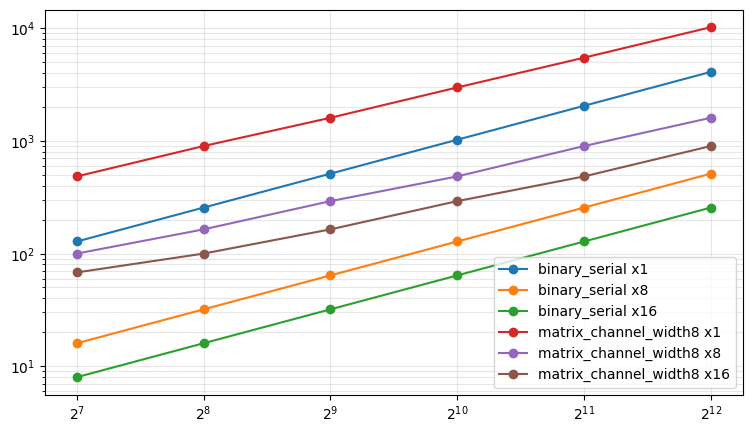

In [3]:
fig,ax=plt.subplots(figsize=(9,5))
for (method,streams),group in df.groupby(['method','streams']):
    if streams in (1,8,16):
        group=group.sort_values('payload_bits'); ax.plot(group['payload_bits'],group['latency_ticks'],marker='o',label=f'{method} x{streams}')
ax.set_xscale('log',base=2); ax.set_yscale('log',base=10); ax.legend(); ax.grid(True,which='both',alpha=.3)

## Read the Table / Как читать таблицу

**RU.** `digit_count` у matrix-fractal означает число mixed-radix разрядов на один stream segment. У binary serial это просто число бит в segment. Поэтому сравнивать нужно не `digit_count`, а `latency_ticks`, `streams` и итоговую плотность `id`.

**EN.** For matrix-fractal, `digit_count` means mixed-radix digits per stream segment. For binary serial, it is just segment bits. Compare latency and information density, not raw digit counts.

In [4]:
summary = (
    df.groupby(['method', 'streams'])
    .agg(
        min_latency=('latency_ticks', 'min'),
        max_latency=('latency_ticks', 'max'),
        mean_id=('id', 'mean'),
        max_id=('id', 'max'),
    )
    .reset_index()
)
summary

,method,streams,min_latency,max_latency,mean_id,max_id
0,binary_serial,1,128,4096,1.000000,1.000000
1,binary_serial,4,32,1024,1.000000,1.000000
2,binary_serial,8,16,512,1.000000,1.000000
3,binary_serial,16,8,256,1.000000,1.000000
4,matrix_channel_width8,1,484,10212,0.331138,0.401097
5,matrix_channel_width8,4,164,2980,0.271006,0.343624
6,matrix_channel_width8,8,100,1604,0.240402,0.319202
7,matrix_channel_width8,16,68,900,0.206809,0.284444
